# Lab 6: PyTorch and Actor-Critic Methods

**MSDS 684 — Reinforcement Learning**  
**Author:** Morgan Cooper

This notebook implements **Part 2** of Lab 6: an online Actor-Critic algorithm with TD(0) bootstrapping, applied to a continuous-action Gymnasium environment (`Pendulum-v1`). The companion report (`Cooper_Morgan_Lab6.pdf`) is built from `generate_report.py`.

**Reading:** Sutton & Barto Ch. 13 (Policy Gradient Methods).

**Notebook outline:**
1. Setup & PyTorch sanity check
2. Environment exploration (`Pendulum-v1`)
3. Actor network — Gaussian policy ($\mu(s)$, $\log\sigma(s)$)
4. Critic network — state-value $V(s)$
5. Online Actor-Critic training loop (TD(0))
6. Visualization — return per episode
7. Visualization — policy entropy over time
8. Visualization — sample trajectories
9. Visualization — TD-error magnitude
10. Visualization — learned mean action across state space
11. Download figures for report

## Part 1: Setup & PyTorch Sanity Check

Install dependencies (uncomment the first time), import libraries, set seeds, and confirm PyTorch is wired up. Pendulum lives in `gymnasium[classic_control]`.

**TODO:** confirm versions print without error and `torch.cuda.is_available()` matches your hardware.

In [1]:
# %pip install torch gymnasium numpy matplotlib
# %pip install "gymnasium[classic_control]"

In [2]:
import os
import math
import time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Bump this before every training run so figures auto-snapshot to figures/v{N}/.
# The latest copy always lives at figures/<name> (what generate_report.py reads).
RUN_VERSION = 7

FIG_LATEST = "figures"
FIG_VERSION_DIR = f"figures/v{RUN_VERSION}"

def save_fig(fig, name):
    """Save to figures/<name> AND figures/v{RUN_VERSION}/<name>."""
    os.makedirs(FIG_LATEST, exist_ok=True)
    os.makedirs(FIG_VERSION_DIR, exist_ok=True)
    fig.savefig(f"{FIG_LATEST}/{name}", dpi=150)
    fig.savefig(f"{FIG_VERSION_DIR}/{name}", dpi=150)

print(f"torch     : {torch.__version__}")
print(f"gymnasium : {gym.__version__}")
print(f"device    : {DEVICE}")
print(f"run version: v{RUN_VERSION} -> figures saved to {FIG_VERSION_DIR} and {FIG_LATEST}")

torch     : 2.10.0
gymnasium : 1.2.3
device    : cpu
run version: v7 -> figures saved to figures/v7 and figures


## Part 2: Environment Exploration — `Pendulum-v1`

Inspect the state and action spaces so we know the right input/output shapes for the actor and critic networks.

- **State space:** 3-dim `Box`, $[\cos\theta, \sin\theta, \dot\theta]$. The angle is decomposed to avoid a 0/2π discontinuity.  
- **Action space:** 1-dim `Box` in $[-2, 2]$ (torque).  
- **Reward:** $-(\theta^2 + 0.1\,\dot\theta^2 + 0.001\,a^2)$ per step. Best possible is 0; worst around $-16$.  
- **Episode termination:** fixed-length 200 steps (no terminal state — a *truncation* by time limit).

**TODO:** run the random rollout and confirm the printed bounds match the description above.

In [3]:
ENV_ID = "Pendulum-v1"

env = gym.make(ENV_ID)
obs_space = env.observation_space
act_space = env.action_space

print("Observation space:", obs_space)
print("  low :", obs_space.low)
print("  high:", obs_space.high)
print()
print("Action space:", act_space)
print("  low :", act_space.low)
print("  high:", act_space.high)
print()

# Random-policy rollout for sanity
for ep in range(3):
    obs, _ = env.reset(seed=ep)
    total_reward, steps, done = 0.0, 0, False
    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += float(reward)
        steps += 1
        done = terminated or truncated
    print(f"Episode {ep}: steps={steps}, total_reward={total_reward:.2f}")

env.close()

Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
  low : [-1. -1. -8.]
  high: [1. 1. 8.]

Action space: Box(-2.0, 2.0, (1,), float32)
  low : [-2.]
  high: [2.]

Episode 0: steps=200, total_reward=-965.84
Episode 1: steps=200, total_reward=-877.29
Episode 2: steps=200, total_reward=-1160.56


## Part 3: Actor Network — Gaussian Policy

The actor outputs the parameters of a Gaussian over actions: a state-dependent mean $\mu(s)$ and a state-independent (or state-dependent) log standard deviation $\log\sigma$. We sample with `torch.distributions.Normal(mu, sigma)` and clip the sample to the env's action bounds before passing to `env.step`.

**Design choices to document in the report:**
- Hidden layer sizes & activation (start: `[64, 64]`, `tanh`).
- Initial `log_std` (start: `0.0` → $\sigma=1$). Lower init = less exploration; higher = more.
- Whether `log_std` is a learned scalar parameter or a function of state. Scalar is simpler and is the canonical S&B 13.7 setup.

**TODO:** instantiate the actor, do a forward pass on a dummy state, and verify the output shapes.

In [4]:
class GaussianActor(nn.Module):
    """Gaussian policy: outputs mean per state, learns a scalar log-std.

    v2 fix: tanh-squash mu into action_scale * [-1, 1] so the pre-clip mean
    cannot drift far outside the env action range. Without this, mu(s) saturated
    at +-15 on Pendulum (action range +-2), torch.clamp did all the work, and
    the Gaussian collapsed to bang-bang.
    """

    def __init__(self, obs_dim, act_dim, hidden=(64, 64), init_log_std=0.0,
                 action_scale=2.0):
        super().__init__()
        layers = []
        prev = obs_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.Tanh()]
            prev = h
        self.trunk = nn.Sequential(*layers)
        self.mu_head = nn.Linear(prev, act_dim)
        self.action_scale = action_scale
        # Learned scalar log-std (one per action dim)
        self.log_std = nn.Parameter(torch.full((act_dim,), float(init_log_std)))

    def forward(self, obs):
        h = self.trunk(obs)
        mu = torch.tanh(self.mu_head(h)) * self.action_scale  # v2: squash to action range
        # v6: clamp tightened further [-2.0, -0.7] -> sigma in [0.135, ~0.50].
        # v5 reached -312 best return but log_std still pinned at the clamp; smaller
        # max sigma forces finer-grained actions, which should help the balance phase.
        log_std = self.log_std.clamp(min=-2.0, max=-0.7)
        std = log_std.exp().expand_as(mu)
        return mu, std

    def dist(self, obs):
        mu, std = self.forward(obs)
        return Normal(mu, std)


# TODO: sanity-check shapes
_actor = GaussianActor(obs_dim=3, act_dim=1).to(DEVICE)
_dummy = torch.zeros(1, 3, device=DEVICE)
_mu, _std = _actor(_dummy)
print("mu :", _mu.shape, _mu.detach().cpu().numpy())
print("std:", _std.shape, _std.detach().cpu().numpy())

mu : torch.Size([1, 1]) [[0.04424287]]
std: torch.Size([1, 1]) [[0.4965853]]


## Part 4: Critic Network — State Value $V(s)$

The critic estimates $V(s)$ and provides the bootstrapped TD target. The actor uses the TD error $\delta = r + \gamma V(s') - V(s)$ (detached) as its advantage signal, while the critic minimizes $\delta^2$ via MSE.

**TODO:** confirm the forward pass returns a scalar per state.

In [5]:
class ValueCritic(nn.Module):
    """State-value network V(s)."""

    def __init__(self, obs_dim, hidden=(64, 64)):
        super().__init__()
        layers = []
        prev = obs_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.Tanh()]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, obs):
        return self.net(obs).squeeze(-1)


_critic = ValueCritic(obs_dim=3).to(DEVICE)
print("V(s) shape:", _critic(_dummy).shape)

V(s) shape: torch.Size([1])


## Part 5: Online Actor-Critic Training Loop (TD(0))

Per-step update rule (Sutton & Barto §13.5):

1. Sample action $a \sim \pi_\theta(\cdot \mid s)$, step env to get $r, s'$.
2. Compute $\delta = r + \gamma V_w(s')(1 - \text{done}) - V_w(s)$.
3. Critic loss: $\delta^2$ → backprop into $V_w$.
4. Actor loss: $-\log\pi_\theta(a \mid s) \cdot \delta_{\text{detach}}$ → backprop into $\pi_\theta$.
5. (Optional) entropy bonus to encourage exploration.

**Bugs to watch for** (and to document in the AI Use Reflection if you hit them):
- forgetting `.detach()` on $\delta$ when computing actor loss → gradients flow through the critic and destabilize
- wrong sign on policy loss
- not summing `log_prob` across action dims for multi-dim continuous actions
- forgetting to clip the sampled action to `env.action_space` bounds
- forgetting `optimizer.zero_grad()` between updates

**TODO:** run training for `NUM_EPISODES` and watch the moving-average return climb. Pendulum is solved-ish around $-200$ to $-150$ average return.

In [6]:
# Hyperparameters — document these in the report
NUM_EPISODES = 1200
GAMMA = 0.99
ACTOR_LR = 3e-4
CRITIC_LR = 1e-3
HIDDEN = (64, 64)
INIT_LOG_STD = 0.0
ENTROPY_COEF = 0.01  # v5: small entropy bonus so optimiser balances exploration vs reward


def train_actor_critic(seed=0, num_episodes=NUM_EPISODES, verbose=True):
    env = gym.make(ENV_ID)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    act_low = torch.tensor(env.action_space.low, device=DEVICE, dtype=torch.float32)
    act_high = torch.tensor(env.action_space.high, device=DEVICE, dtype=torch.float32)

    torch.manual_seed(seed)
    np.random.seed(seed)

    actor = GaussianActor(obs_dim, act_dim, hidden=HIDDEN, init_log_std=INIT_LOG_STD).to(DEVICE)
    critic = ValueCritic(obs_dim, hidden=HIDDEN).to(DEVICE)
    actor_opt = torch.optim.Adam(actor.parameters(), lr=ACTOR_LR)
    critic_opt = torch.optim.Adam(critic.parameters(), lr=CRITIC_LR)

    history = {
        "return": [],
        "entropy": [],   # average policy entropy across the episode
        "td_abs": [],    # mean |delta| per episode
    }

    # v3: track best moving-avg policy so catastrophic forgetting at the end
    # of training does not overwrite a good intermediate policy.
    best_avg = -float("inf")
    best_actor_state = None
    best_critic_state = None
    BEST_WINDOW = 25

    for ep in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total_reward = 0.0
        ep_entropies, ep_td_abs = [], []
        done = False

        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
            dist = actor.dist(obs_t)
            action = dist.sample()
            log_prob = dist.log_prob(action).sum()        # sum across action dims
            entropy = dist.entropy().sum()

            # Clip to env bounds before stepping
            action_clipped = torch.clamp(action, act_low, act_high)
            action_np = action_clipped.cpu().numpy()
            next_obs, reward, terminated, truncated, _ = env.step(action_np)
            done = terminated or truncated
            total_reward += float(reward)   # log raw env reward for return curve comparability

            # v7: dual reward shaping when near upright. v6 only penalised
            # actions, which let the agent settle at a tilted gravity-balanced
            # equilibrium with constant torque ~ -1.25. v7 penalises both tilt
            # AND action magnitude, so the only Pareto-optimal balance is
            # theta ~ 0 with small corrective torque (active stabilisation).
            cos_n, sin_n, theta_dot_n = next_obs
            theta_n = math.atan2(float(sin_n), float(cos_n))
            near_balance = abs(theta_n) < 0.3 and abs(theta_dot_n) < 1.0
            shaped_reward = reward
            if near_balance:
                shaped_reward -= 0.3 * (theta_n ** 2)                       # strong tilt penalty
                shaped_reward -= 0.05 * float(np.sum(action_np ** 2))       # action penalty (kept from v6)

            # v7+: explicit bonus for hitting a tight "perfectly upright" window.
            # Rewards FRACTION OF STEPS spent within ~3 deg of vertical with low spin,
            # which is the practical proxy for "balances perfectly upright".
            perfect_upright = abs(theta_n) < 0.05 and abs(theta_dot_n) < 0.3
            if perfect_upright:
                shaped_reward += 0.5

            next_obs_t = torch.as_tensor(next_obs, dtype=torch.float32, device=DEVICE)
            v_s = critic(obs_t)
            with torch.no_grad():
                v_next = critic(next_obs_t) * (0.0 if terminated else 1.0)
                td_target = shaped_reward + GAMMA * v_next   # train on shaped reward
            delta = td_target - v_s

            # Critic update (with grad clipping for v3 stability)
            critic_loss = delta.pow(2)
            critic_opt.zero_grad()
            critic_loss.backward()
            torch.nn.utils.clip_grad_norm_(critic.parameters(), max_norm=1.0)
            critic_opt.step()

            # Actor update — detach delta so gradients don't flow through critic
            actor_loss = -(log_prob * delta.detach()) - ENTROPY_COEF * entropy
            actor_opt.zero_grad()
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=1.0)
            actor_opt.step()

            ep_entropies.append(entropy.item())
            ep_td_abs.append(delta.abs().item())
            obs = next_obs

        history["return"].append(total_reward)
        history["entropy"].append(float(np.mean(ep_entropies)))
        history["td_abs"].append(float(np.mean(ep_td_abs)))

        # v3: snapshot best policy by moving-avg return
        if len(history["return"]) >= BEST_WINDOW:
            avg_now = float(np.mean(history["return"][-BEST_WINDOW:]))
            if avg_now > best_avg:
                best_avg = avg_now
                best_actor_state = {k: v.detach().clone() for k, v in actor.state_dict().items()}
                best_critic_state = {k: v.detach().clone() for k, v in critic.state_dict().items()}

        if verbose and (ep + 1) % 50 == 0:
            avg = np.mean(history["return"][-50:])
            print(f"ep {ep+1:4d} | last-50 return {avg:8.2f} | log_std {actor.log_std.detach().cpu().numpy()}")

    env.close()

    # v3: load best policy back into the live actor/critic before returning
    if best_actor_state is not None:
        actor.load_state_dict(best_actor_state)
        critic.load_state_dict(best_critic_state)
        history["best_avg_return"] = best_avg
        if verbose:
            print(f"restored best policy: {BEST_WINDOW}-ep avg return = {best_avg:.2f}")
    return actor, critic, history


actor, critic, history = train_actor_critic(seed=SEED)

ep   50 | last-50 return -1548.03 | log_std [0.]
ep  100 | last-50 return -1561.14 | log_std [0.]
ep  150 | last-50 return -1339.47 | log_std [0.]
ep  200 | last-50 return -1475.27 | log_std [0.]
ep  250 | last-50 return -1490.38 | log_std [0.]
ep  300 | last-50 return -1410.16 | log_std [0.]
ep  350 | last-50 return -1413.44 | log_std [0.]
ep  400 | last-50 return -1402.94 | log_std [0.]
ep  450 | last-50 return -1520.70 | log_std [0.]
ep  500 | last-50 return -1321.39 | log_std [0.]
ep  550 | last-50 return -1536.50 | log_std [0.]
ep  600 | last-50 return -1511.91 | log_std [0.]
ep  650 | last-50 return -1431.42 | log_std [0.]
ep  700 | last-50 return -1407.27 | log_std [0.]
ep  750 | last-50 return -1459.23 | log_std [0.]
ep  800 | last-50 return -1508.83 | log_std [0.]
ep  850 | last-50 return -1451.29 | log_std [0.]
ep  900 | last-50 return -1518.00 | log_std [0.]
ep  950 | last-50 return -1410.38 | log_std [0.]
ep 1000 | last-50 return -1385.51 | log_std [0.]
ep 1050 | last-50 re

### Save trained model checkpoints

Use `torch.save()` so the report can claim a reproducible run.

In [7]:
os.makedirs("context/checkpoints", exist_ok=True)
torch.save(actor.state_dict(), "context/checkpoints/actor.pt")
torch.save(critic.state_dict(), "context/checkpoints/critic.pt")
print("saved context/checkpoints/actor.pt and context/checkpoints/critic.pt")

saved context/checkpoints/actor.pt and context/checkpoints/critic.pt


## Part 6: Visualization — Return per Episode

Plot raw episode return and a moving average. For confidence intervals, run multiple seeds (see the optional multi-seed cell) and report the mean ± 95% CI. The lab directions emphasize *interpretive* captions — the figure caption in the report should explain **why** the curve looks the way it does (e.g., critic warm-up phase, exploration collapse), not just describe it.

**TODO:** save the figure to `figures/figure1.png` so `generate_report.py` picks it up.

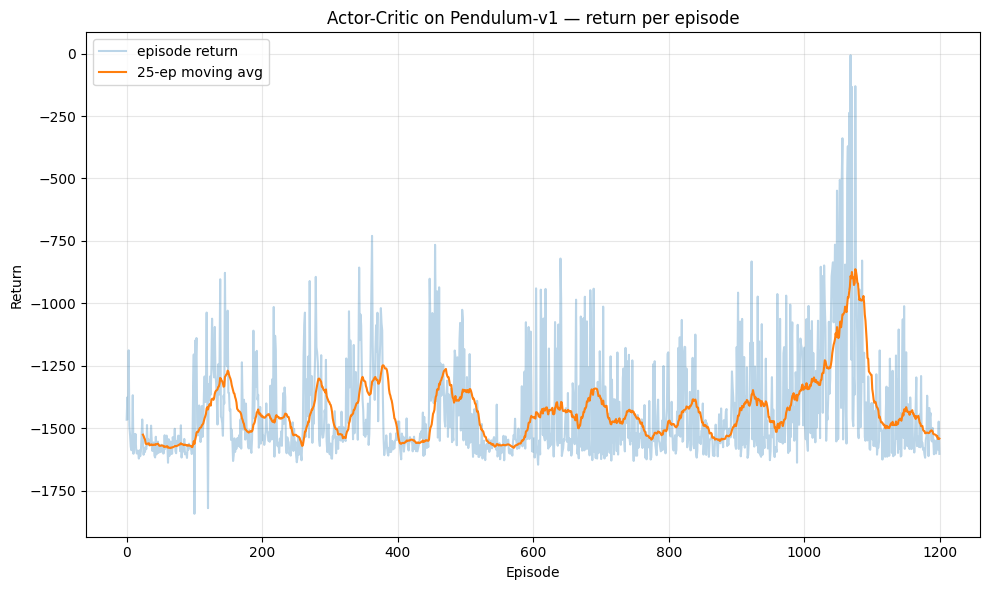

In [8]:
returns = np.array(history["return"])
window = 25
moving = np.convolve(returns, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots()
ax.plot(returns, alpha=0.3, label="episode return")
ax.plot(np.arange(window - 1, len(returns)), moving, label=f"{window}-ep moving avg")
ax.set_xlabel("Episode")
ax.set_ylabel("Return")
ax.set_title("Actor-Critic on Pendulum-v1 — return per episode")
ax.legend()
fig.tight_layout()
save_fig(fig, "figure1.png")
plt.show()

### (Optional) Multi-seed run for confidence intervals

The directions ask for ≥10 seeds (30 ideal). Skip this if compute-bound, but document the limitation. Each seed retrains from scratch.

=== 30-seed sweep, 1200 episodes each ===
  seed  0/30: best=  -939.8  (296.9s | total   4.9m | eta 143.5m)
  seed  1/30: best=  -733.9  (296.2s | total   9.9m | eta 138.4m)
  seed  2/30: best=  -259.0  (296.1s | total  14.8m | eta 133.4m)
  seed  3/30: best=  -623.3  (296.5s | total  19.8m | eta 128.4m)
  seed  4/30: best=  -675.9  (292.4s | total  24.6m | eta 123.2m)
  seed  5/30: best= -1241.4  (293.4s | total  29.5m | eta 118.1m)
  seed  6/30: best=  -709.6  (290.8s | total  34.4m | eta 112.9m)
  seed  7/30: best=  -805.8  (286.8s | total  39.2m | eta 107.7m)
  seed  8/30: best=  -787.2  (288.5s | total  44.0m | eta 102.6m)
  seed  9/30: best= -1466.3  (292.3s | total  48.8m | eta  97.7m)
  seed 10/30: best=  -211.5  (292.3s | total  53.7m | eta  92.8m)
  seed 11/30: best= -1303.1  (292.2s | total  58.6m | eta  87.9m)
  seed 12/30: best=  -546.1  (292.0s | total  63.4m | eta  83.0m)
  seed 13/30: best=  -698.3  (292.9s | total  68.3m | eta  78.1m)
  seed 14/30: best=  -717.6  (293.

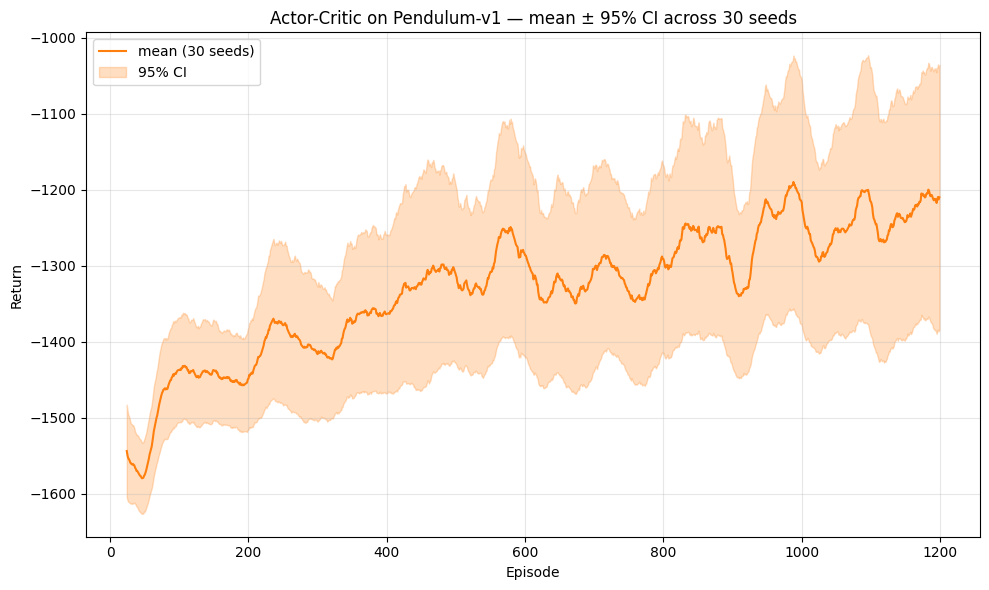


best-policy 25-ep avg across 30 seeds:
  mean =  -850.67
  std  =   346.43
  best =  -211.45
  worst= -1518.76


In [9]:
# v7 multi-seed sweep: train NUM_SEEDS independent agents to compute
# mean +- 95% CI of return across seeds. Lab directions: 30 ideal, 10 min.
# Each seed trains from scratch (own network init, own env reset seeds), so
# total wall time ~= NUM_SEEDS * single-run time. With NUM_EPISODES=1200 and
# 30 seeds expect roughly 30-60 minutes on CPU.
import time as _time

NUM_SEEDS = 30

print(f"=== {NUM_SEEDS}-seed sweep, {NUM_EPISODES} episodes each ===")
multi_seed_returns = []
multi_seed_best = []
t0 = _time.time()
for s in range(NUM_SEEDS):
    t_seed = _time.time()
    _a, _c, h = train_actor_critic(seed=s, verbose=False)
    multi_seed_returns.append(h["return"])
    multi_seed_best.append(h.get("best_avg_return", float("nan")))
    dt = _time.time() - t_seed
    total = _time.time() - t0
    eta = (total / (s + 1)) * (NUM_SEEDS - s - 1)
    print(f"  seed {s:2d}/{NUM_SEEDS}: best={multi_seed_best[-1]:8.1f}  "
          f"({dt:5.1f}s | total {total/60:5.1f}m | eta {eta/60:5.1f}m)")

multi_seed_returns = np.array(multi_seed_returns)
multi_seed_best = np.array(multi_seed_best)
np.save(f"{FIG_LATEST}/multi_seed_returns.npy", multi_seed_returns)
np.save(f"{FIG_VERSION_DIR}/multi_seed_returns.npy", multi_seed_returns)

# Mean +- 95% CI across seeds, smoothed with a 25-ep moving window
mean = multi_seed_returns.mean(axis=0)
sem = multi_seed_returns.std(axis=0, ddof=1) / np.sqrt(NUM_SEEDS)
ci_half = 1.96 * sem

win = 25
def _smooth(x): return np.convolve(x, np.ones(win) / win, mode="valid")
mean_s = _smooth(mean)
upper_s = _smooth(mean + ci_half)
lower_s = _smooth(mean - ci_half)
xs = np.arange(win - 1, len(mean))

fig, ax = plt.subplots()
ax.plot(xs, mean_s, color="C1", label=f"mean ({NUM_SEEDS} seeds)")
ax.fill_between(xs, lower_s, upper_s, color="C1", alpha=0.25, label="95% CI")
ax.set_xlabel("Episode")
ax.set_ylabel("Return")
ax.set_title(f"Actor-Critic on Pendulum-v1 — mean ± 95% CI across {NUM_SEEDS} seeds")
ax.legend()
fig.tight_layout()
save_fig(fig, "figure1.png")   # overwrite the single-seed return curve
plt.show()

print(f"\nbest-policy 25-ep avg across {NUM_SEEDS} seeds:")
print(f"  mean = {np.nanmean(multi_seed_best):8.2f}")
print(f"  std  = {np.nanstd(multi_seed_best):8.2f}")
print(f"  best = {np.nanmax(multi_seed_best):8.2f}")
print(f"  worst= {np.nanmin(multi_seed_best):8.2f}")


## Part 7: Visualization — Policy Entropy Over Time

Track $\mathcal{H}[\pi]$ across training. For a Gaussian, entropy is monotone in $\sigma$, so this also visualizes how the policy sharpens. A healthy curve decays gradually; a cliff means exploration collapsed before the critic could give useful gradients.

**TODO:** save to `figures/figure2.png`.

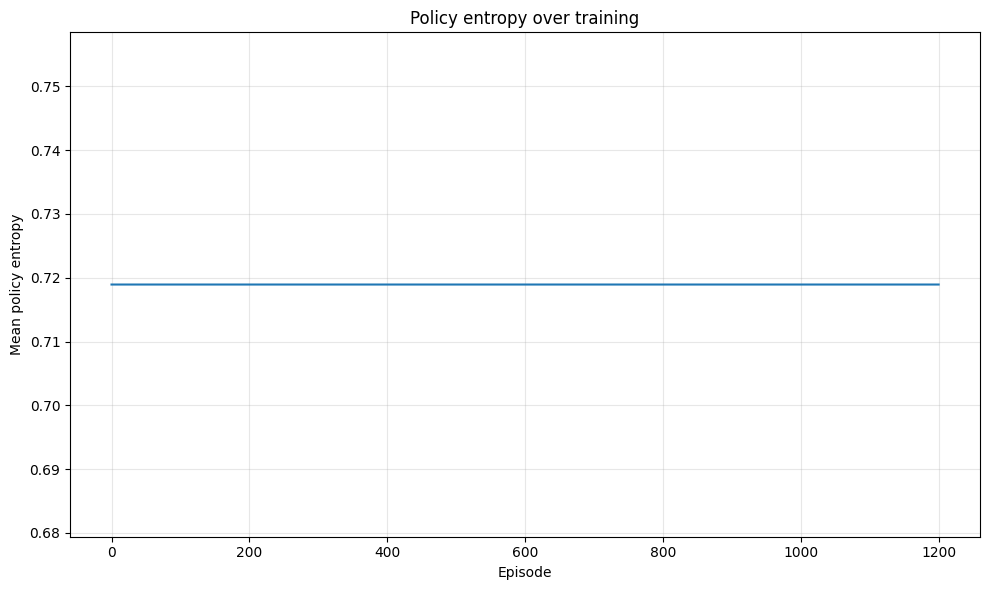

In [10]:
fig, ax = plt.subplots()
ax.plot(history["entropy"])
ax.set_xlabel("Episode")
ax.set_ylabel("Mean policy entropy")
ax.set_title("Policy entropy over training")
fig.tight_layout()
save_fig(fig, "figure2.png")
plt.show()

## Part 8: Visualization — Sample Trajectories

Roll out the trained policy *deterministically* (use the mean, not a sample) and plot $\theta(t)$ and $\dot\theta(t)$. A solved policy swings the pendulum upright and holds it: $\theta \to 0$, $\dot\theta \to 0$.

**TODO:** save to `figures/figure3.png`.

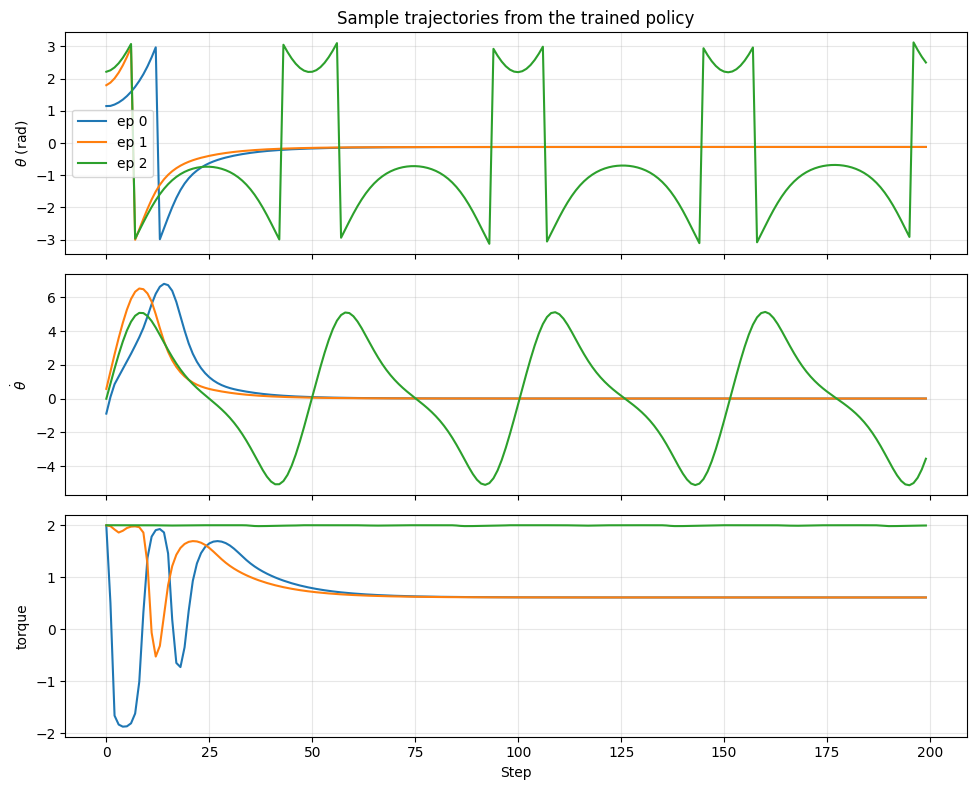

In [11]:
def rollout_deterministic(actor, num_episodes=3, seed=123):
    env = gym.make(ENV_ID)
    trajectories = []
    for ep in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep)
        traj = []
        done = False
        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
            with torch.no_grad():
                mu, _ = actor(obs_t)
            action = torch.clamp(
                mu,
                torch.tensor(env.action_space.low, device=DEVICE),
                torch.tensor(env.action_space.high, device=DEVICE),
            ).cpu().numpy()
            cos_t, sin_t, theta_dot = obs
            theta = math.atan2(sin_t, cos_t)
            traj.append((theta, theta_dot, float(action[0])))
            obs, _, term, trunc, _ = env.step(action)
            done = term or trunc
        trajectories.append(np.array(traj))
    env.close()
    return trajectories


trajs = rollout_deterministic(actor, num_episodes=3)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i, traj in enumerate(trajs):
    axes[0].plot(traj[:, 0], label=f"ep {i}")
    axes[1].plot(traj[:, 1], label=f"ep {i}")
    axes[2].plot(traj[:, 2], label=f"ep {i}")
axes[0].set_ylabel(r"$\theta$ (rad)")
axes[1].set_ylabel(r"$\dot\theta$")
axes[2].set_ylabel("torque")
axes[2].set_xlabel("Step")
axes[0].legend(); axes[0].set_title("Sample trajectories from the trained policy")
fig.tight_layout()
save_fig(fig, "figure3.png")
plt.show()

### Trained Agent Video

Render the trained policy as a GIF so the balancing behaviour is visually obvious.
Uses `seed=124`, which corresponds to **ep 1** in the trajectory plot above — the
episode where $\theta \to 0$ and $\dot\theta \to 0$. Saves to
`figures/trained_policy.gif` and `figures/v{RUN_VERSION}/trained_policy.gif`.

In [12]:
from matplotlib import animation
from IPython.display import HTML, display

# Pick the seed that produced a balanced episode in figure3 (ep 1 = seed 124).
BALANCED_SEED = 124
MAX_FRAMES = 400

render_env = gym.make(ENV_ID, render_mode="rgb_array")
act_low_t = torch.tensor(render_env.action_space.low, device=DEVICE, dtype=torch.float32)
act_high_t = torch.tensor(render_env.action_space.high, device=DEVICE, dtype=torch.float32)

obs, _ = render_env.reset(seed=BALANCED_SEED)
frames = []
for _ in range(MAX_FRAMES):
    frames.append(render_env.render())
    obs_t = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        mu, _ = actor(obs_t)
    action = torch.clamp(mu, act_low_t, act_high_t).cpu().numpy()
    obs, _, term, trunc, _ = render_env.step(action)
    if term or trunc:
        frames.append(render_env.render())
        break
render_env.close()
print(f"recorded {len(frames)} frames")

# Build an inline HTML5 player with play / pause / scrub controls.
fig, ax = plt.subplots(figsize=(5, 5))
ax.axis("off")
fig.tight_layout(pad=0)
im = ax.imshow(frames[0])

def _update(frame):
    im.set_array(frame)
    return [im]

anim = animation.FuncAnimation(fig, _update, frames=frames, interval=33, blit=True)
plt.close(fig)  # suppress the static frame; only show the animation

# Save GIF (universal, autoplays) + try to save MP4 for higher-quality scrubbing.
os.makedirs(FIG_VERSION_DIR, exist_ok=True)
gif_paths = [f"{FIG_LATEST}/trained_policy.gif", f"{FIG_VERSION_DIR}/trained_policy.gif"]
for p in gif_paths:
    anim.save(p, writer=animation.PillowWriter(fps=30))
print(f"saved GIFs -> {gif_paths}")

mp4_paths = [f"{FIG_LATEST}/trained_policy.mp4", f"{FIG_VERSION_DIR}/trained_policy.mp4"]
try:
    for p in mp4_paths:
        anim.save(p, writer=animation.FFMpegWriter(fps=30))
    print(f"saved MP4s -> {mp4_paths}")
except (FileNotFoundError, RuntimeError, ValueError) as e:
    print(f"MP4 export skipped (no ffmpeg in PATH): {e}")

display(HTML(anim.to_jshtml()))   # interactive player with play/pause/scrub


recorded 201 frames
saved GIFs -> ['figures/trained_policy.gif', 'figures/v7/trained_policy.gif']
saved MP4s -> ['figures/trained_policy.mp4', 'figures/v7/trained_policy.mp4']


## Part 9: Visualization — TD-Error Magnitude

Mean $|\delta|$ per episode. Should trend down as the critic's $V(s)$ estimate sharpens. If it plateaus high, the critic isn't keeping up — try a higher critic LR or more critic capacity.

**TODO:** save to `figures/figure4.png`.

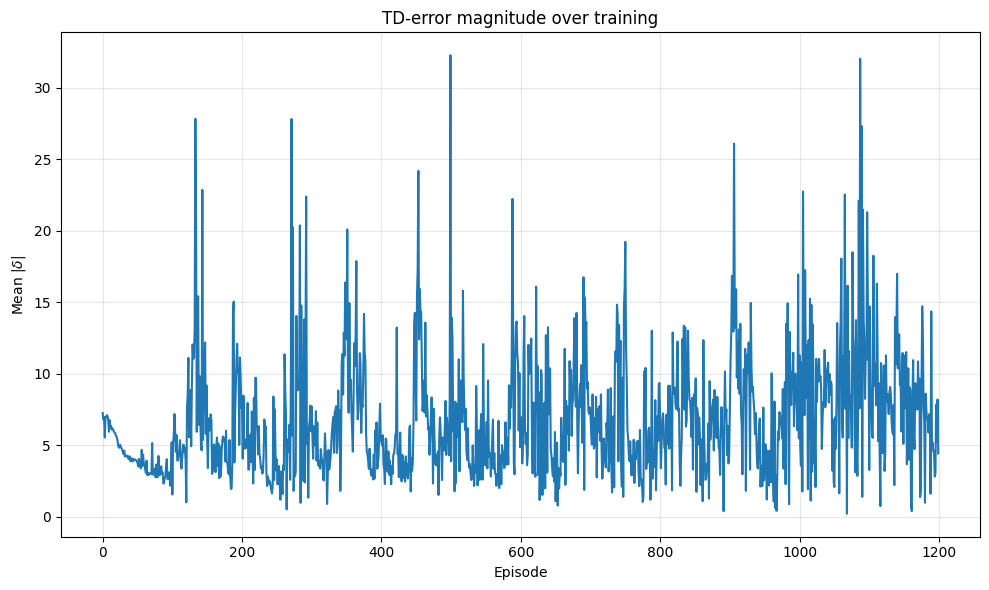

In [13]:
fig, ax = plt.subplots()
ax.plot(history["td_abs"])
ax.set_xlabel("Episode")
ax.set_ylabel(r"Mean $|\delta|$")
ax.set_title("TD-error magnitude over training")
fig.tight_layout()
save_fig(fig, "figure4.png")
plt.show()

## Part 10: (Bonus) Mean Action Across the State Space

The directions ask: *"Save and visualize the learned policy by plotting the actor's mean action across the state space."* Pendulum's state is 3-dim; we slice through $\dot\theta = 0$ and plot $\mu(s)$ over $\theta \in [-\pi, \pi]$, mapped to $[\cos\theta, \sin\theta, 0]$.

**TODO:** save to `figures/policy_heatmap.png` (this one is a bonus, not in the main 4 figures).

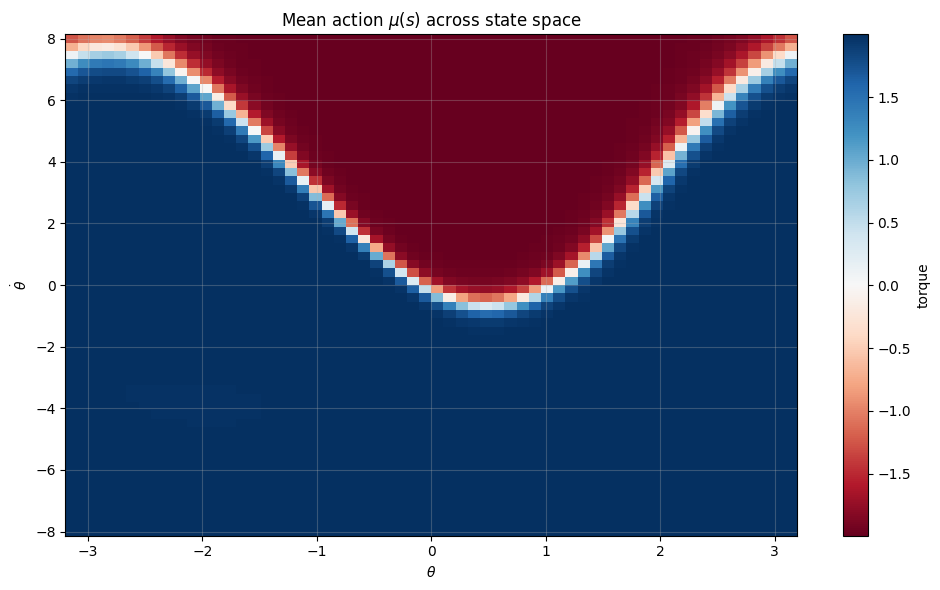

In [14]:
thetas = np.linspace(-np.pi, np.pi, 60)
theta_dots = np.linspace(-8.0, 8.0, 60)
T, TD = np.meshgrid(thetas, theta_dots)
states = np.stack([np.cos(T), np.sin(T), TD], axis=-1).reshape(-1, 3)
with torch.no_grad():
    states_t = torch.as_tensor(states, dtype=torch.float32, device=DEVICE)
    mu, _ = actor(states_t)
mu_grid = mu.cpu().numpy().reshape(T.shape)

fig, ax = plt.subplots()
im = ax.pcolormesh(T, TD, mu_grid, cmap="RdBu", shading="auto")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\dot\theta$")
ax.set_title(r"Mean action $\mu(s)$ across state space")
fig.colorbar(im, ax=ax, label="torque")
fig.tight_layout()
save_fig(fig, "policy_heatmap.png")
plt.show()

## Part 11: Download Figures for Report

Quick check that all four required figures exist before running `python generate_report.py`.

In [15]:
required = ["figures/figure1.png", "figures/figure2.png", "figures/figure3.png", "figures/figure4.png"]
for f in required:
    status = "OK" if os.path.exists(f) else "MISSING"
    print(f"{status:8s} {f}")

OK       figures/figure1.png
OK       figures/figure2.png
OK       figures/figure3.png
OK       figures/figure4.png
